# Isotropic coordinate system transformations

Radial basis functions are *isotropic*: they depend only on $\|x - c\|$, so the model assumes the response varies at the same rate in every direction. Real responses rarely do. The mismatch shows up as model bias, and it is why adding gradient information to a surrogate can fail to improve it — the extra information ends up fighting the functional form rather than informing it.

The fix is a pre-processing step: estimate a rotation and a per-direction scaling that make the data manifold roughly isotropic, express the samples *and their gradients* in that frame, and fit there.

This notebook uses the paper's test problem, which is decomposable by construction, so the ideal frame is known exactly. Rotating it couples the variables, and a transformation scheme then has to recover both a rotation and a scaling.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import qmc

from ge_rbf import IsotropicTransformer, RBFRegressor, gradient_search
from ge_rbf.problems import non_isotropic, random_rotation

rotation = random_rotation(2, rng=5)

X = qmc.LatinHypercube(d=2, seed=1).random(15)
y, dy = non_isotropic(X, rotation)

print(f"{X.shape[0]} samples in {X.shape[1]} dimensions")
print("rotation used to couple the variables:")
print(np.round(rotation, 4))

15 samples in 2 dimensions
rotation used to couple the variables:
[[ 0.6064  0.7952]
 [-0.7952  0.6064]]


## Estimating the frame

The transformer estimates curvature, then takes its eigenvectors as the rotation and the square roots of its eigenvalues as the scaling. `"ge-lhm"` builds local Hessians from the sampled gradients using symmetric rank-one updates — it needs only `n + 1` points per estimate, so it scales linearly with dimension.

In [2]:
frame = IsotropicTransformer(method="ge-lhm").fit(X, y=y, dy=dy)

print("estimated curvature:")
print(np.round(frame.curvature_, 3))
print(f"\neigenvalues: {np.round(frame.eigenvalues_, 3)}")
print(f"scaling:     {np.round(frame.scaling_, 3)}")
print(f"\nanisotropy ratio: {frame.eigenvalues_[0] / frame.eigenvalues_[-1]:.1f}x")

estimated curvature:
[[19.233 10.892]
 [10.892 11.407]]

eigenvalues: [26.893  3.747]
scaling:     [5.186 1.936]

anisotropy ratio: 7.2x


The transformer holds the frame and nothing else — it never modifies the estimator or the data you give it. You apply it explicitly, and gradients need their own conversion because rotating and scaling the coordinates changes what a gradient means.

In [3]:
X_frame = frame.transform(X)
dy_frame = frame.transform_gradient(dy)

# Round trips exactly.
print(f"inverse_transform recovers X:  {np.allclose(frame.inverse_transform(X_frame), X)}")
print(
    f"and the gradients:             {np.allclose(frame.inverse_transform_gradient(dy_frame), dy)}"
)

inverse_transform recovers X:  True
and the gradients:             True


## Does it help?

Fit a gradient-enhanced model both ways, selecting the shape parameter independently in each frame so the comparison is fair, and measure the error on a dense grid.

In [4]:
grid = np.linspace(0, 1, 60)
gx, gy = np.meshgrid(grid, grid)
points = np.column_stack([gx.ravel(), gy.ravel()])
truth, _ = non_isotropic(points, rotation)


def fit_and_score(transformer=None):
    """Select a shape parameter and fit, optionally in a transformed frame."""
    if transformer is None:
        fit_X, fit_dy, test_X = X, dy, points
    else:
        fit_X = transformer.transform(X)
        fit_dy = transformer.transform_gradient(dy)
        test_X = transformer.transform(points)

    found = gradient_search(RBFRegressor(), fit_X, y, fit_dy, max_condition=1e13)
    prediction = found.best_estimator.predict(test_X)
    return prediction, np.linalg.norm(prediction - truth) / np.linalg.norm(truth), found


baseline, baseline_error, baseline_search = fit_and_score()
transformed, transformed_error, transformed_search = fit_and_score(frame)

print(
    f"original frame:    eps={baseline_search.best_epsilon:.3f}, relative error {baseline_error:.2%}"
)
print(
    f"transformed frame: eps={transformed_search.best_epsilon:.3f}, relative error {transformed_error:.2%}"
)

original frame:    eps=1.389, relative error 9.18%
transformed frame: eps=0.054, relative error 2.83%


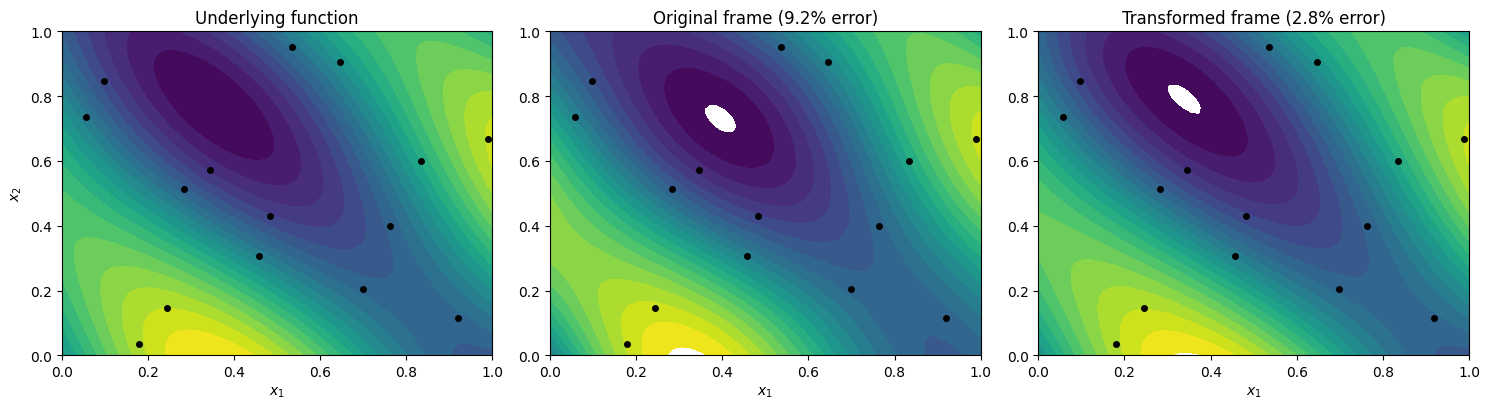

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
levels = np.linspace(truth.min(), truth.max(), 21)

for ax, (field, title) in zip(
    axes,
    [
        (truth, "Underlying function"),
        (baseline, f"Original frame ({baseline_error:.1%} error)"),
        (transformed, f"Transformed frame ({transformed_error:.1%} error)"),
    ],
    strict=True,
):
    ax.contourf(gx, gy, field.reshape(gx.shape), levels=levels)
    ax.plot(X[:, 0], X[:, 1], "k.", markersize=8)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")

axes[0].set_ylabel("$x_2$")
fig.tight_layout()

## Comparing the estimation methods

- **`ge-lhm`** — local Hessians from gradients. Needs `n + 1` points per estimate.
- **`ge-dlhm`** — the same, but keeping only the diagonal: component-wise scaling with no rotation. This is what conventional cross-validated scaling amounts to, and on a coupled problem it should help noticeably less.
- **`fv-lhm`** — local quadratic fits to function values. Needs `n(n+1)/2 + n + 1` points per estimate, so it becomes expensive quickly.
- **`asm`** — the active subspace method: one global measure rather than many local ones.
- **`ideal`** — a frame you supply. Here we know the answer, so we can supply it.

In [6]:
results = {"no transformation": baseline_error}

for method in ("ge-lhm", "ge-dlhm", "fv-lhm", "asm"):
    candidate = IsotropicTransformer(method=method).fit(X, y=y, dy=dy)
    results[method] = fit_and_score(candidate)[1]

# The ideal frame uses the exact rotation the problem was built with. The scaling
# still has to come from somewhere, so we estimate curvature in the decomposable
# frame and take its diagonal -- in axis order, not sorted, so that each scaler
# stays paired with the axis it belongs to.
decomposable = IsotropicTransformer(method="ge-lhm").fit(X @ rotation, dy=dy @ rotation)
ideal = IsotropicTransformer(
    method="ideal", rotation=rotation, scaling=np.sqrt(np.diag(decomposable.curvature_))
).fit(X)
results["ideal"] = fit_and_score(ideal)[1]

for name, error in sorted(results.items(), key=lambda item: item[1]):
    print(f"{name:>20s}: {error:.2%}")

               ideal: 2.39%
              fv-lhm: 2.46%
              ge-lhm: 2.83%
                 asm: 4.63%
             ge-dlhm: 9.01%
   no transformation: 9.18%


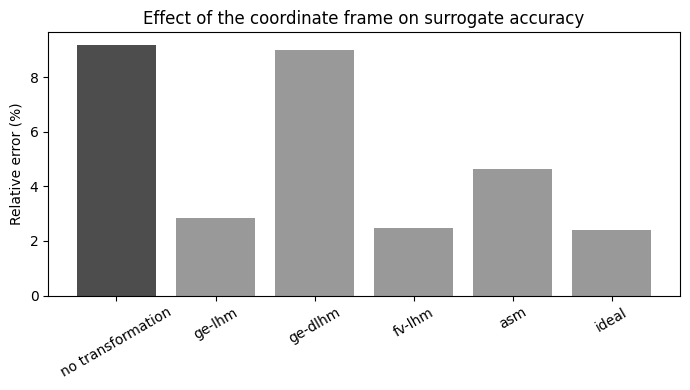

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
names = list(results)
ax.bar(names, [results[n] * 100 for n in names], color="0.6")
ax.bar(["no transformation"], [results["no transformation"] * 100], color="0.3")
ax.set_ylabel("Relative error (%)")
ax.set_title("Effect of the coordinate frame on surrogate accuracy")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()

The ordering is the paper's argument in miniature. The `ideal` frame — the exact rotation the problem was built with — is best, and the two methods that estimate a *full rotation* from local curvature (`fv-lhm`, `ge-lhm`) land close behind it on this handful of samples.

The instructive one is `ge-dlhm`, which is `ge-lhm` with the rotation thrown away: it barely improves on doing nothing at all. Component-wise scaling is what conventional cross-validation amounts to, and on a problem whose variables are coupled it has almost nothing to work with — the anisotropy is not aligned with the coordinate axes, so scaling those axes cannot reach it. `asm` sits in between: it does find a rotation, but from one global average rather than a collection of local estimates.

## Higher dimensions, more samples

Two samples of the same problem tell you little. The question that matters for practice is whether the transformation still earns its keep as the problem grows — and whether it is merely a small-sample crutch that a denser design would make redundant.

So: sweep the problem dimension from 2 to 16, and at each dimension sweep the design size. Sample counts are quoted **per dimension**, since a fixed number of samples means something very different in 2-D than in 16-D. Everything else is held fixed — a gradient-enhanced model both times, with `gradient_search` picking the shape parameter independently in each frame so that neither is handicapped by a setting chosen for the other.

Each configuration is repeated with different random rotations and designs, and the median reported, because a single unlucky Latin hypercube draw can move the error by more than the effect being measured.

In [8]:
DIMENSIONS = (2, 4, 8, 16)
SAMPLES_PER_DIMENSION = (5, 10, 20)
REPEATS = 3
EPSILONS = np.logspace(-2, 1, 25)


def trial(n_features, per_dimension, seed):
    """Fit a GE-RBF in both frames on one random problem. Returns the two errors."""
    n_samples = n_features * per_dimension
    coupling = random_rotation(n_features, rng=seed)

    samples = qmc.LatinHypercube(d=n_features, seed=seed).random(n_samples)
    values, gradients = non_isotropic(samples, coupling)

    # A large independent test set: this is the number we actually care about.
    test = qmc.LatinHypercube(d=n_features, seed=seed + 1000).random(2000)
    test_truth, _ = non_isotropic(test, coupling)

    def error(transformer=None):
        if transformer is None:
            fit_X, fit_dy, test_X = samples, gradients, test
        else:
            fit_X = transformer.transform(samples)
            fit_dy = transformer.transform_gradient(gradients)
            test_X = transformer.transform(test)

        found = gradient_search(
            RBFRegressor(), fit_X, values, fit_dy, epsilons=EPSILONS, max_condition=1e13
        )
        prediction = found.best_estimator.predict(test_X)
        return np.linalg.norm(prediction - test_truth) / np.linalg.norm(test_truth)

    estimated = IsotropicTransformer(method="ge-lhm").fit(samples, dy=gradients)
    return error(), error(estimated)


study = {}
for n_features in DIMENSIONS:
    for per_dimension in SAMPLES_PER_DIMENSION:
        pairs = [
            trial(n_features, per_dimension, seed=100 * n_features + 10 * per_dimension + r)
            for r in range(REPEATS)
        ]
        plain, framed = np.median(pairs, axis=0)
        study[n_features, per_dimension] = (plain, framed)
        print(
            f"{n_features:2d}-D, {per_dimension:2d} samples/dim (n={n_features * per_dimension:3d}): "
            f"original {plain:6.1%}   transformed {framed:6.1%}   improvement {plain / framed:4.2f}x"
        )

 2-D,  5 samples/dim (n= 10): original  50.2%   transformed  17.7%   improvement 2.83x
 2-D, 10 samples/dim (n= 20): original   3.7%   transformed   2.8%   improvement 1.35x


 2-D, 20 samples/dim (n= 40): original   0.3%   transformed   0.2%   improvement 1.58x
 4-D,  5 samples/dim (n= 20): original  61.3%   transformed  33.3%   improvement 1.84x


 4-D, 10 samples/dim (n= 40): original  36.0%   transformed  13.7%   improvement 2.63x


 4-D, 20 samples/dim (n= 80): original  17.5%   transformed   7.5%   improvement 2.34x


 8-D,  5 samples/dim (n= 40): original  79.0%   transformed  53.0%   improvement 1.49x


 8-D, 10 samples/dim (n= 80): original  61.6%   transformed  36.7%   improvement 1.68x


 8-D, 20 samples/dim (n=160): original  45.9%   transformed  22.4%   improvement 2.05x


16-D,  5 samples/dim (n= 80): original  74.9%   transformed  66.7%   improvement 1.12x


16-D, 10 samples/dim (n=160): original  64.6%   transformed  49.2%   improvement 1.31x


16-D, 20 samples/dim (n=320): original  60.6%   transformed  43.9%   improvement 1.38x


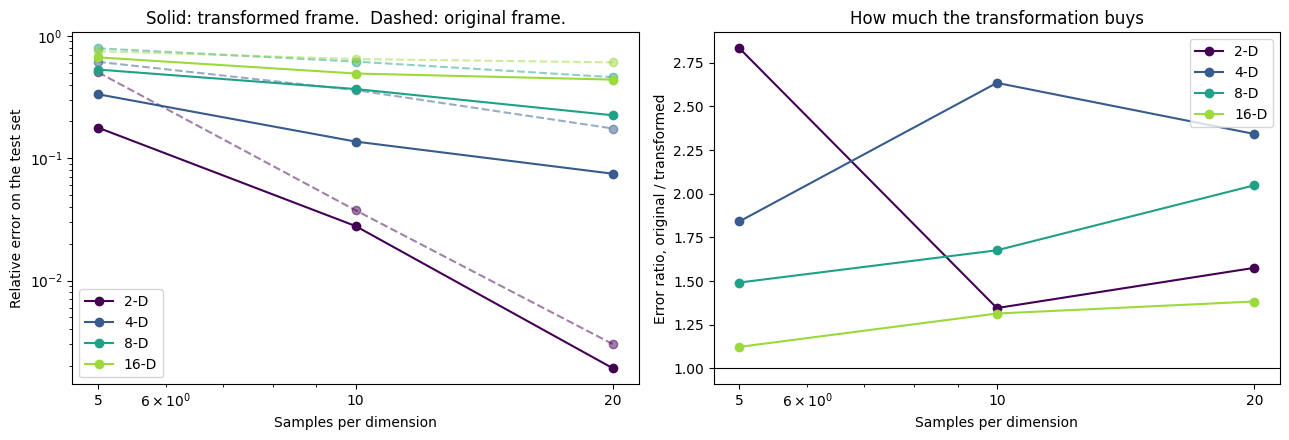

In [9]:
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5))
colours = plt.cm.viridis(np.linspace(0, 0.85, len(DIMENSIONS)))

for colour, n_features in zip(colours, DIMENSIONS, strict=True):
    plain = [study[n_features, s][0] for s in SAMPLES_PER_DIMENSION]
    framed = [study[n_features, s][1] for s in SAMPLES_PER_DIMENSION]

    left.plot(SAMPLES_PER_DIMENSION, plain, "o--", color=colour, alpha=0.5)
    left.plot(SAMPLES_PER_DIMENSION, framed, "o-", color=colour, label=f"{n_features}-D")
    right.plot(
        SAMPLES_PER_DIMENSION,
        [p / f for p, f in zip(plain, framed, strict=True)],
        "o-",
        color=colour,
        label=f"{n_features}-D",
    )

left.set_yscale("log")
left.set_xscale("log")
left.set_xticks(SAMPLES_PER_DIMENSION, [str(s) for s in SAMPLES_PER_DIMENSION])
left.set_xlabel("Samples per dimension")
left.set_ylabel("Relative error on the test set")
left.set_title("Solid: transformed frame.  Dashed: original frame.")
left.legend()

right.axhline(1.0, color="k", lw=0.8)
right.set_xscale("log")
right.set_xticks(SAMPLES_PER_DIMENSION, [str(s) for s in SAMPLES_PER_DIMENSION])
right.set_xlabel("Samples per dimension")
right.set_ylabel("Error ratio, original / transformed")
right.set_title("How much the transformation buys")
right.legend()

fig.tight_layout()

**The transformation helps everywhere.** Every ratio in the right-hand panel is above 1, at every dimension and every design size. Nothing here is a small-sample artefact.

**But the trend with sample count runs in opposite directions at the two ends.** In 2-D the advantage is largest when data is scarce and shrinks once there is enough of it — by 20 samples per dimension both frames are under half a percent, and the problem is easy enough that the coordinate system stops mattering much. In 8-D and 16-D the opposite happens: the advantage *grows* as samples are added.

That reversal is worth dwelling on, because it says something about what limits the method. The frame is not free information — it is estimated from the same samples. `ge-lhm` needs `n + 1` points for each local curvature estimate, so at 5 samples per dimension in 16-D there is barely enough data to form a frame at all, and it earns only 1.12x. Add samples and the estimate sharpens, and the payoff rises to 1.38x and is still climbing. In low dimensions the frame is already well estimated at the smallest design, so extra samples go into the surrogate instead and the two frames converge.

**In absolute terms, 16-D stays hard.** At 20 samples per dimension — 320 evaluations, with gradients — the surrogate is still tens of percent out in either frame. The transformation is not a substitute for samples. What recommends it is the price: a fixed pre-processing step that, for `ge-lhm`, costs a local estimate over `n + 1` neighbours per point and so grows only linearly with dimension.

## A caveat

The test problem here is decomposable, so an ideal frame genuinely exists and the methods can find it. On a problem whose Hessian varies strongly across the domain there may be no single global frame worth finding, and the transformation will offer little. Section 7 of the paper covers this limitation.